In [14]:

library(tidyverse)
library(readr)
library(lubridate)
library(IRdisplay)
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 150)

holdout_weeks <- 104  # adjust as desired (e.g. 52 or 104)
season_lag_weeks <- 104 # approx. 2 years (52*2). Adjust if you prefer a date-based join

source("transformations.R")
# ilinet <- readr::read_rds('data/fluview_clean/ilinet_clean.rds')
df <- read.csv("data/fluview_clean/ilinet_final.csv") 

In [2]:
print_function <- function(rmse_in_sample, rmse_holdout, model_name){
    cat(paste0(model_name, " RMSE - In Sample: ", round(rmse_in_sample, 4), " | Holdout: ", round(rmse_holdout, 4), "\n"))
}

## Data preparation for basic models

In [15]:
# First we need to remove or NA values form the data set
source("./df.R")

data<- split_data(df$ilitotal,remove.missing = T)

train = data$train
holdout = data$holdout

calculate_rmse <- function(train, holdout,predict_func) {
  n <- length(train)
  sse<-0
  fc<-predict_func(train)
  yt<-holdout[1]
  fc_error<-expm1(yt)-expm1(fc)
  sse<-sse+fc_error^2
  for (i in 2:length(holdout)) {
    fc<-predict_func(c(train, holdout[1:(i-1)]))
    yt<-holdout[i]
    fc_error<-expm1(yt)-expm1(fc)
    sse<-sse+fc_error^2
  }
  mse<-sse/length(holdout)
  return(sqrt(mse))
}

### Persistence
[x] Persistence model

In [20]:

persistence_predict <- function(train){
    return (train[length(train)])
}
# surely we can write an MSE function to just evaluate this for any model since the predict is based on the observed data.
# as it is rolling 1 step forcast

rmse_out_sample <- calculate_rmse(train,holdout,persistence_predict)

# how do we use this to calculate the in-sample error? we can just use the same function but with the train data as the holdout and a smaller train set.
rmse_in_sample <- calculate_rmse(c(train[1]),train[2:length(train)],persistence_predict)

print_function(rmse_in_sample, rmse_out_sample, "Persistence")

Persistence RMSE - In Sample: 4591.421 | Holdout: 13862.3583


### Average
[x] Average model

In [21]:

average_predict <- function(train){    
    return (logp1(mean(expm1(train))))
}
rmse_out_sample <- calculate_rmse(train,holdout,average_predict)
rmse_in_sample <- calculate_rmse(c(train[1]),train[2:length(train)],average_predict)
print_function(rmse_in_sample, rmse_out_sample, "Average")

Average RMSE - In Sample: 24425.026 | Holdout: 70756.748


### IID
[x] IID model


In [22]:
# lastly we will aso just check the final baseline which is IID
# ts_train<- data$ts
weekly_mean<- tapply(expm1(train),cycle(train),mean)
holdout_iid <- logp1(weekly_mean[cycle(holdout)])
# ts.plot(holdout_iid, main="Holdout vs IID Forecast", xlab="IID Forecast", ylab="Holdout")
rmse_out_sample <- sqrt(mean((expm1(holdout)-expm1(holdout_iid))^2))
rmse_in_sample <- sqrt(mean((expm1(train)-weekly_mean[cycle(train)])^2))
print_function(rmse_in_sample, rmse_out_sample, "IID")
residuals <- expm1(holdout) - expm1(holdout_iid)
# plot(factor(holdout_iid),residuals)



IID RMSE - In Sample: 22315.5799 | Holdout: 67731.8984


## Holt Winters
[x] Holt Winters 

In [23]:
# now we will implement exponential smoothing and see how it performs. We will use the HoltWinters function from the stats package which is a simple implementation of exponential smoothing. We will use the default parameters which are alpha = 0.2, beta = 0.1, and gamma = 0.1. We will also use the forecast function from the forecast package to make predictions.
library(forecast)
# Fit the Holt-Winters model to the training data
# ts_train
fit_HW <- HoltWinters(train, seasonal = "additive")
# 

advanced_rmse_1_step <- function(train,holdout,fit_func){
    sse <- 0
    forecasts <- numeric(length(holdout))
    current_series <- train
    for(i in 1:length(holdout)) {
      fit <- fit_func(current_series)
      forecasts[i] <- predict(fit, n.ahead = 1)
      sse <- sse+ (forecasts[i]-holdout[i])^2
      current_series <- ts(c(current_series, holdout[i]),frequency = frequency(train),start = start(train))
    }
    rmse_os <- sqrt(mean((expm1(forecasts)-expm1(holdout))^2)) # we only care about the out of sample rmse.
    return(list(rmse_os = rmse_os,forecasts = forecasts))
}

# we loook at the insample error by just fitting the model to the whole training data and then calculating the rmse on the training data.

in_sample_forecast <- fitted(fit_HW)
rmse_in_sample <- sqrt(mean((expm1(in_sample_forecast) - expm1(train))^2))
HW_add <- function(x) HoltWinters(x, seasonal = "additive")
forecast_obj <- advanced_rmse_1_step(train,holdout, HW_add)  
rmse_out_sample <- forecast_obj$rmse_os
print_function(rmse_in_sample, rmse_out_sample, "Holt-Winters (Additive)")

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Warning message in HoltWinters(x, seasonal = "additive"):
“optimization difficulties: ERROR: ABNORMAL_TERMINATION_IN_LNSRCH”


Holt-Winters (Additive) RMSE - In Sample: 28896.9937 | Holdout: 17400.1611


In [12]:
ts_train_diff <- diff(train, differences = 1)

acf(ts_tain_diff)
fit_arima <- auto.arima(ts_train_diff,)

summary(fit_arima)

ERROR: Error: object 'ts_tain_diff' not found


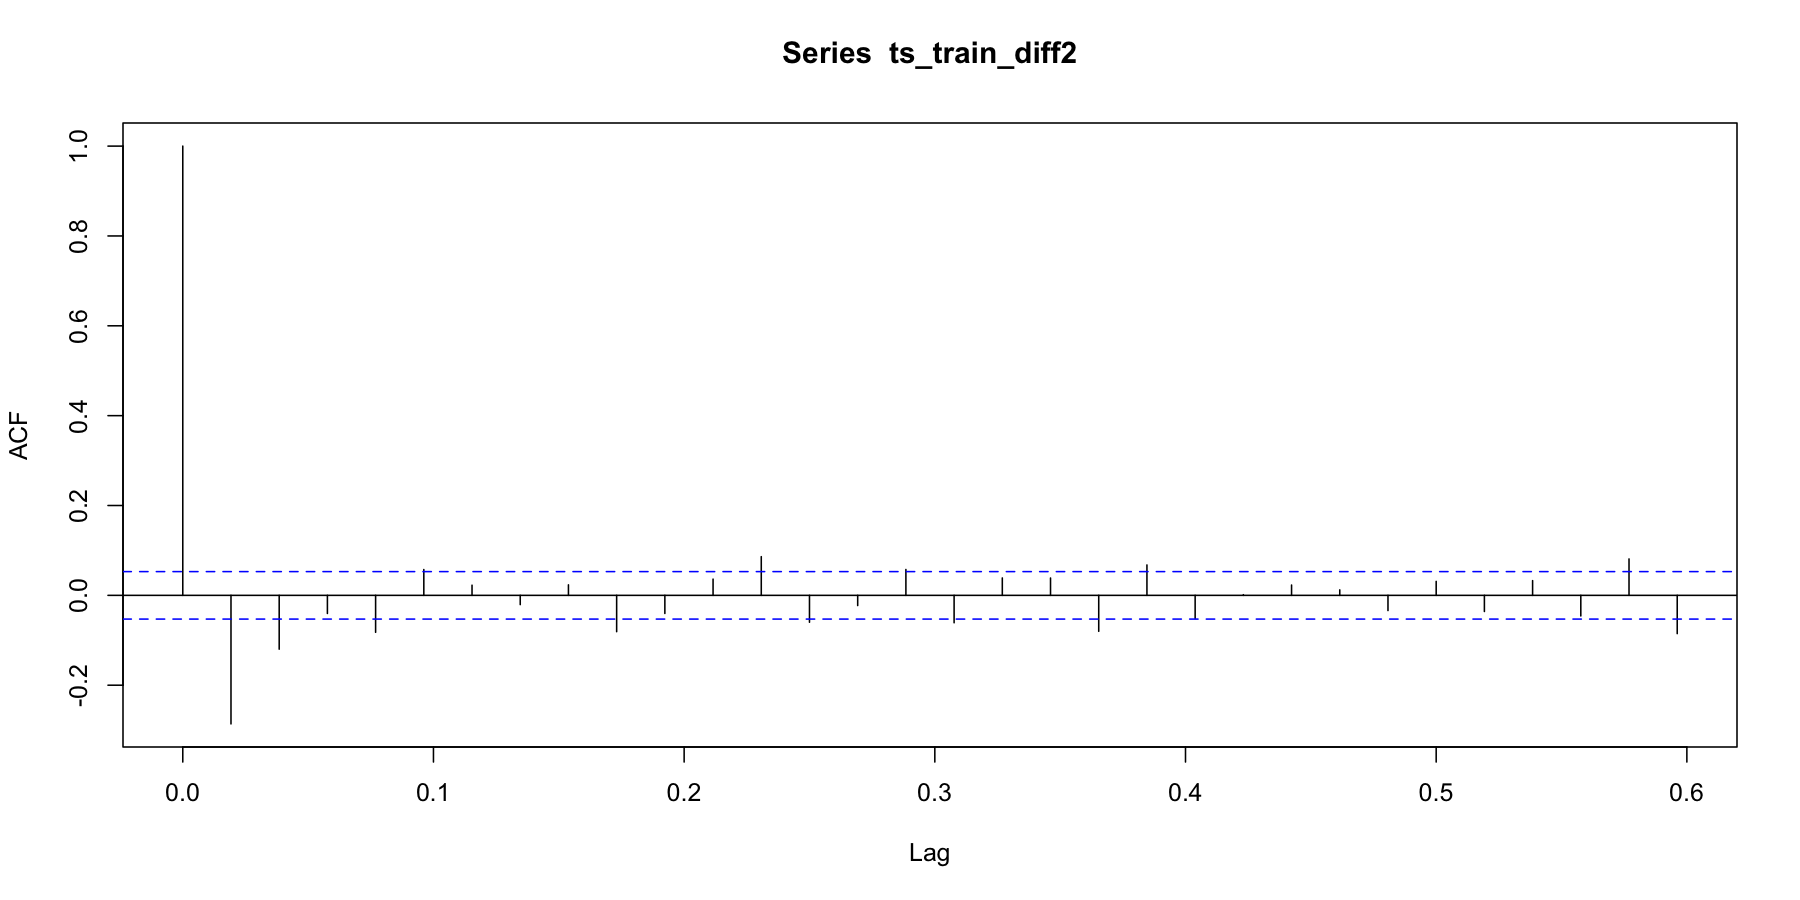

In [ ]:
# now that we do this we will need to calculate the 
ts_train_diff2 = diff(ts_train_diff,lag = 1)
acf(ts_train_diff2)


In [ ]:

#advanced_fit_func(current_model, current_series)
advanced_fc <- function(train,holdout,advanced_fit_func,model){
    sse <- 0
    forecasts <- numeric(length(holdout))
    current_series <- train
    current_model <- model

    for(i in 1:length(holdout)) {
      clear_output(wait = TRUE)
      display_text(paste("Calculating: ",round(i/length(holdout)*100, 2), "%"))
      fit <- advanced_fit_func(current_model, current_series)
      forecasts[i] <- predict(fit, n.ahead = 1)$pred
      sse <- sse+ (forecasts[i]-holdout[i])^2
      current_model <- fit
      current_series <- ts(c(current_series, holdout[i]),frequency = frequency(train),start = start(train))
    }
    rmse_os <- sqrt(mean((forecasts-holdout)^2)) # we only care about the out of sample rmse.
    return(list(rmse_os = rmse_os,forecasts = forecasts))
}




# fit




In [ ]:
dif_train = diff(train)
ntrain <- length(train)

# seasonal difference lag 12 after difference at lag 1
sdif_dif_train = dif_train[-(1:52)]- dif_train[-((ntrain-52):(ntrain-1))]

# spec.pgram(sdif_dif_train,span=c(4,8))

auto_arima_fit <- auto.arima(train)
#  arima(train,order = c(1,1,2),seasonal = list(order = c(0,1,0), period = 52),include.mean = TRUE)
display_text(paste("RMSE: ",sqrt(mean(residuals(auto_arima_fit)^2)), "| AIC: ",auto_arima_fit$aic))
convert_auto_arima_to_arima <- function(auto_arima_model){
    p <- auto_arima_model$arma[1]
    d <- auto_arima_model$arma[6]
    q <- auto_arima_model$arma[2]
    P <- auto_arima_model$arma[3]
    D <- auto_arima_model$arma[7]
    Q <- auto_arima_model$arma[4]
    m <- auto_arima_model$arma[5]
    has_mean <- "intercept" %in% names(coef(auto_arima_model))
    return(list(order = c(p,d,q), seasonal = list(order = c(P,D,Q), period = m), include.mean = has_mean))
}


arima_refit_function <- function(model_structure,data,coeficients){
    arima_fit<- arima(data,order = model_structure$order,seasonal = model_structure$seasonal,include.mean = model_structure$include.mean,init=coeficients)
    return (arima_fit)
}

# arima_advanced_fit <- function(current_model, current_series,model){
#     arima_fit<- arima(current_series,order = model_structure$order,seasonal = model_structure$seasonal,include.mean = model_structure$include.mean,init=coef(current_model))
#     return (arima_fit)
# }
current_model_structure <- convert_auto_arima_to_arima(auto_arima_fit)
arima_advanced_fit = function(current_model, current_series){
    return (arima_refit_function(model_structure =current_model_structure,data = current_series,coeficients = coef(current_model)))
}
advanced_fc(train,holdout,arima_advanced_fit ,model =auto_arima_fit)



# arima_refit_function <- function(arima_model,data,structure)
# fit2 <- arima_refit_function(model_structure,vals,coef(auto_arima_fit))
# fit3 <- arima_refit_function(model_structure,vals,coef(fit2))
# coef(fit3)
# coef(fit2)
# coef(auto_arima_fit)
# predict(fit2,n.ahead = 1)
# predict(fit,n.ahead = 1)
# coef(fit2)
# coef(fit)
# plot(residuals(fit))
# qqnorm(residuals(fit))
# hist(residuals(fit))
# acf(sdif_dif_train,lag.max = 52)
# pacf(sdif_dif_train,lag.max = 52)

In [4]:
auto.arima(train,stepwise    = TRUE,   # default, but make sure it's on
  approximation = TRUE, # uses faster approximation of likelihood
  max.P = 1, max.Q = 1, # limit seasonal AR/MA order
  max.p = 2, max.q = 2, # limit non-seasonal order
  D = 1,                # fix seasonal differencing (you already diff manually)
  trace = TRUE)

ERROR: Error in auto.arima(train, stepwise = TRUE, approximation = TRUE, max.P = 1, : could not find function "auto.arima"


In [ ]:
mod <- auto.arima(train,stepwise    = TRUE,   # default, but make sure it's on
  approximation = TRUE, # uses faster approximation of likelihood
  max.P = 3, max.Q = 3, # limit seasonal AR/MA order
  max.p = 3, max.q = 3, # limit non-seasonal order
  D = 1,           # fix seasonal differencing (you already diff manually)
  trace = TRUE)
residmod <-auto.arima(numeric(residuals(mod)),stepwise    = TRUE,   # default, but make sure it's on
  approximation = TRUE, # uses faster approximation of likelihood
  max.P = 3, max.Q = 3, # limit seasonal AR/MA order
  max.p = 3, max.q = 3, # limit non-seasonal order
  D = 1, m=19,          # fix seasonal differencing (you already diff manually)
  trace = TRUE)
summary(mod)
summary(residmod)


 Fitting models using approximations to speed things up...

 ARIMA(2,0,2)(1,1,1)[52] with drift         : -1414.284
 ARIMA(0,0,0)(0,1,0)[52] with drift         : 1915.533
 ARIMA(1,0,0)(1,1,0)[52] with drift         : -1191.481
 ARIMA(0,0,1)(0,1,1)[52] with drift         : 597.8356
 ARIMA(0,0,0)(0,1,0)[52]                    : 2009.499
 ARIMA(2,0,2)(0,1,1)[52] with drift         : -1132.758
 ARIMA(2,0,2)(1,1,0)[52] with drift         : -1343.564
 ARIMA(2,0,2)(2,1,1)[52] with drift         : -1483.758
 ARIMA(2,0,2)(2,1,0)[52] with drift         : Inf
 ARIMA(2,0,2)(3,1,1)[52] with drift         : Inf
 ARIMA(2,0,2)(2,1,2)[52] with drift         : Inf
 ARIMA(2,0,2)(1,1,2)[52] with drift         : Inf
 ARIMA(2,0,2)(3,1,0)[52] with drift         : -1481.819
 ARIMA(2,0,2)(3,1,2)[52] with drift         : Inf
 ARIMA(1,0,2)(2,1,1)[52] with drift         : -1455.634
 ARIMA(2,0,1)(2,1,1)[52] with drift         : Inf
 ARIMA(3,0,2)(2,1,1)[52] with drift         : Inf
 ARIMA(2,0,3)(2,1,1)[52] with dr

ERROR: Error in auto.arima(numeric(residuals(mod)), stepwise = TRUE, approximation = TRUE, : argument 9 matches multiple formal arguments


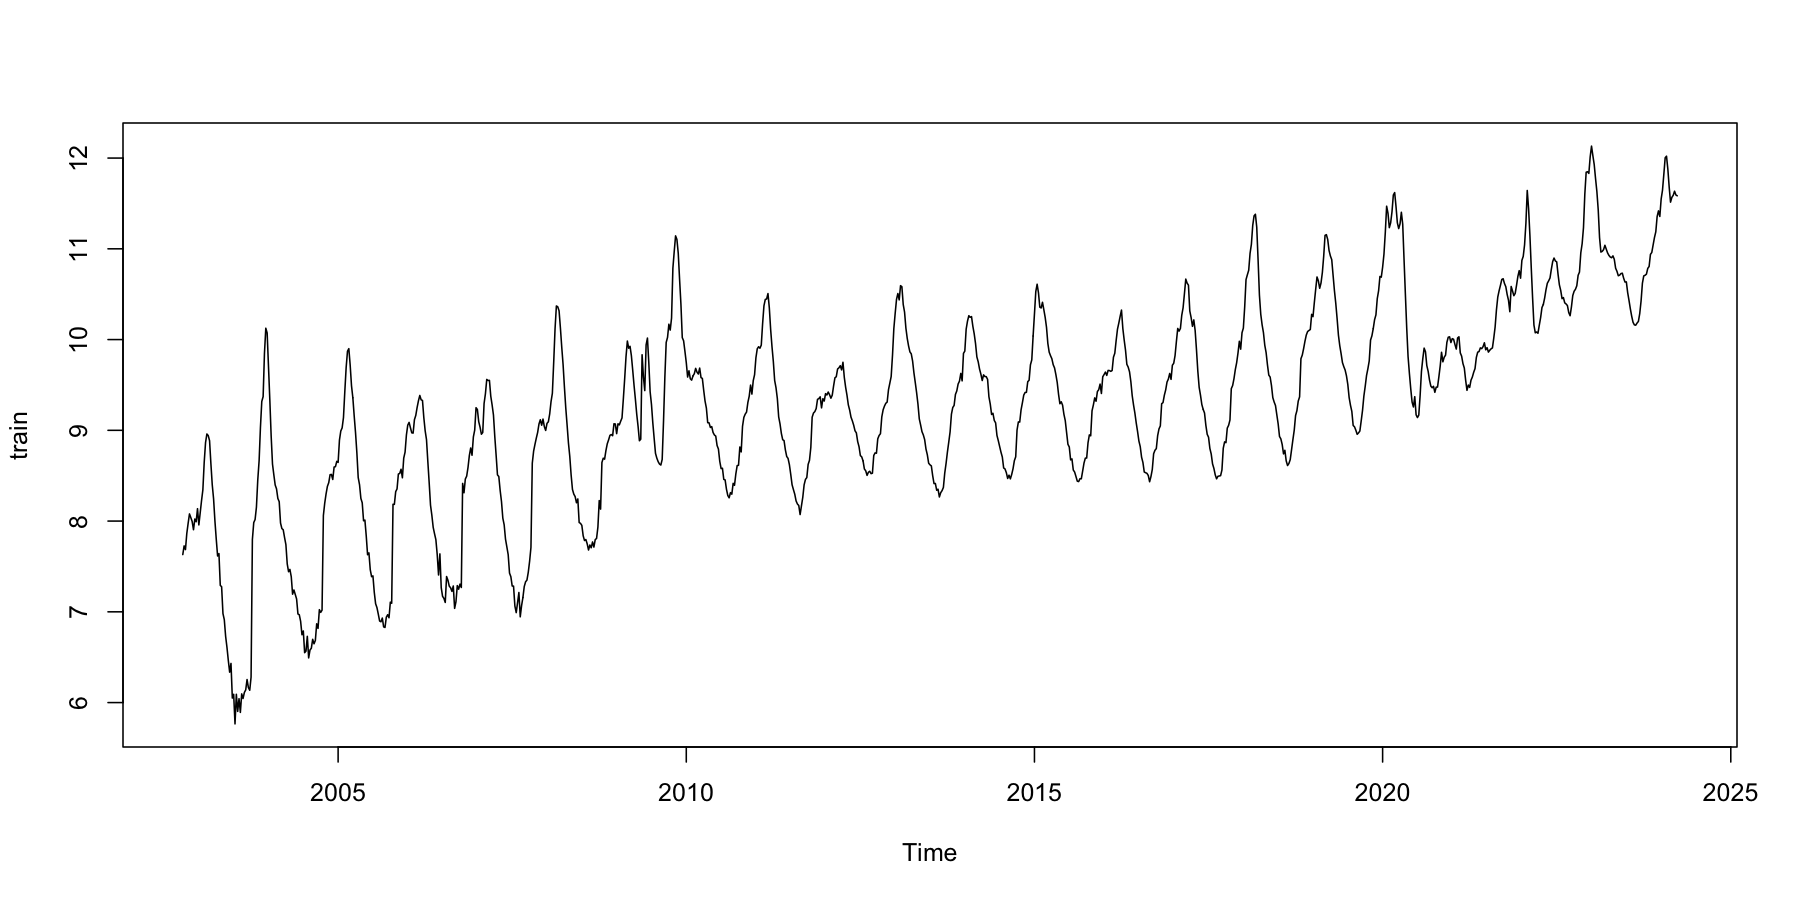

In [ ]:
# TODO